# Building a neural network with PyTorch on MINST dataset

In this book we will use 
- nn.Module is the Base class for all neural network modules. Our models should also subclass this class.
- optim utility packages provided within Pytorch. To do the optimization of the parameters of the model.
- We subclass nn.Module (which itself is a class and able to keep track of state).
- nn.Module has a numbers of attributes and methods (such as .parameters() and .zero_grad()) which we will be using to perform diifferent       operations and operations on the model.

### Creating Deep Learning Model for building a handwritten digit classifier. We will make use of MNIST dataset from torchvision package.

## Data Preprocessing :
Mandatory 1st step is to do the basic data preprocessing steps, using the a utility called transforms which comes from torchvision package.

Steps:
- Transform the raw dataset into tensors.
- Normalize the dataset.

In [2]:
import torch
from torchvision.datasets import MNIST

In [3]:
from torchvision import transforms

In [4]:
# transform : This variable stores multiple preprocessing steps.
transform = transforms.Compose([ #Compose() combines multiple transforms into a pipeline.
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,)) # The values (0.1307,) (0.3081,) used for Normalize() are global mean and standard deviation of MNIST for transformation
])

Flow:
``` python
Image
 ↓
ToTensor()
 ↓
Normalize()
 ↓
Final Tensor
```

transforms.ToTensor(),

Converts image into a PyTorch tensor.

It also scales pixel values:
```python
0 - 255  →  0.0 - 1.0

MNIST image shape changes from:

28 × 28

to tensor shape:

[1, 28, 28]

Where:

1 = grayscale channel
28,28 = image height and width
```

transforms.Normalize((0.1307,), (0.3081,))

Normalizes tensor values.

Formula used internally:

x
normalized
	​

=
σ
x−μ
	​


Where:

μ = mean
σ = standard deviation

For MNIST:
```python
mean = 0.1307
std  = 0.3081
```
#### These are the global mean and standard deviation of the entire MNIST dataset.

Why normalization is used

Normalization helps neural networks:

Train faster
Become more stable
Prevent very large/small values

Without normalization:

Training can become slower
Gradients may behave poorly
Why (0.1307,) has a comma

MNIST is grayscale → only 1 channel.

PyTorch expects:

one mean per channel
one std per channel

So:

(0.1307,)

means:

mean for channel 1

For RGB images it would look like:

(mean_r, mean_g, mean_b)

Example:

Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
Complete Flow
Original Image
(0-255 pixels)
        ↓
ToTensor()
(0-1 values)
        ↓
Normalize()
(centered standardized values)
        ↓
Ready for neural network

In [5]:
# Choose training data 
train_data = MNIST(root= "data", train=True,download=True,transform = transform)

In [6]:
len(train_data)

60000

In [7]:
# Number of subprocesses to use for data loading
num_workers = 0

# how many samples per batch to load
batch_size = 50

In [8]:
import numpy as np 
from torch.utils.data import DataLoader

# Data loader preparation
train_loader = DataLoader(train_data, batch_size= batch_size , num_workers= num_workers)

In [9]:
# Let's check the shape of the input and target data
data_iter = iter(train_loader) # iter() allows you to fetch batches one-by-one.
images, labels = next(data_iter) # Gets the next batch from the iterator.
print(type(images))
print(images.shape)
print(labels.shape)
#32 images each image is 28×28 grayscale = 1

<class 'torch.Tensor'>
torch.Size([50, 1, 28, 28])
torch.Size([50])


In [10]:
# This is how it works
x = [1,2,3]
y = [5,6,7]
z = zip(x,y)
# print(list(z)) # prints [(1, 5), (2, 6), (3, 7)]

a = iter(z)
i , j = next(a)
print(i,j)

i , j = next(a)
print(i,j)

i , j = next(a)
print(i,j)

1 5
2 6
3 7


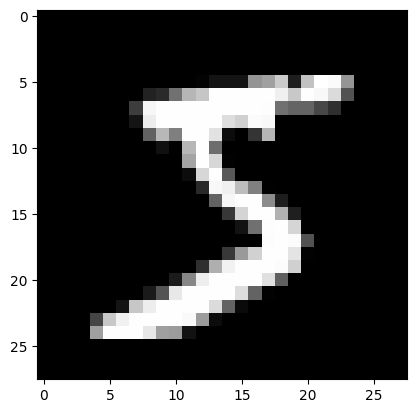

In [11]:
# Checking an sample image data
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(images[0].numpy().squeeze(), cmap = 'Greys_r')

#.numpy() Converts PyTorch tensor → NumPy array. Why? - Because Matplotlib works better with NumPy arrays. 
# before .squeeze (1,28,28) after (28,28) - removed grayscale dimension
#Sets the color map. Greys → grayscale colors _r → reversed colors

In [12]:
# Storing it for prediction once the modle in trained
img_five = images[0]

# Architecture

We create a new class (which inherits the properties from the base class from nn package called Module) to define the architeture of the Neural Network.

In [13]:
from torch import nn, optim
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256,10)

    def forward(self,x):
        # Input tensor is flattened
        x = x.view(x.shape[0],-1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x
        

In [14]:
model = Model()

In [15]:
criterion = nn.CrossEntropyLoss()
from torch import optim

optimizer = optim.SGD(model.parameters(),lr=0.01)

In [16]:
for epoch in range(1,11):
    train_loss = []

    # Training Part
    for data, target in train_loader:
        optimizer.zero_grad()
        # 1. Forward Propogation
        output = model(data)

        # 2. Loss Calculation
        loss = criterion(output,target)

        #3. Backward Propagation
        loss.backward()

        #4. Weight Optimization
        optimizer.step()

        # print(loss.item())
        train_loss.append(loss.item())

    print("Epoch:", epoch, "Training Loss:", np.mean(train_loss))

Epoch: 1 Training Loss: 0.509077514698729
Epoch: 2 Training Loss: 0.26837386208275954
Epoch: 3 Training Loss: 0.21840867842081935
Epoch: 4 Training Loss: 0.1856543141005871
Epoch: 5 Training Loss: 0.16172146016576638
Epoch: 6 Training Loss: 0.14332116201830408
Epoch: 7 Training Loss: 0.12863536578059817
Epoch: 8 Training Loss: 0.11668212701915763
Epoch: 9 Training Loss: 0.10672052735967251
Epoch: 10 Training Loss: 0.09827838565960216


In [17]:
# Calcualtes the class probabilities (softmax) for img
log_ps = model(img_five) # log_ps is log probabilities
ps = torch.exp(log_ps)

In [18]:
print(ps)
print(ps.shape)

tensor([[3.8710e-01, 1.9811e-01, 4.8331e+00, 3.2862e+03, 4.0653e-05, 1.2172e+05,
         5.2883e-03, 9.4937e-01, 1.5245e-01, 2.8695e-01]],
       grad_fn=<ExpBackward0>)
torch.Size([1, 10])


In [19]:
top_p, top_class = ps.topk(1,dim=1)

In [20]:
top_p

tensor([[121720.7812]], grad_fn=<TopkBackward0>)

In [21]:
top_class

tensor([[5]])

# Checking Accuracy on the 1st Batch

In [22]:
log_ps = model(images)
ps = torch.exp(log_ps)

In [23]:
top_p , top_class = ps.topk(1, dim=1)

In [24]:
# Look at the most likely examples for the first 10 examples
print(top_class[:10,:])

tensor([[5],
        [0],
        [4],
        [1],
        [9],
        [2],
        [1],
        [3],
        [1],
        [4]])


In [25]:
top_class.shape , labels.shape

(torch.Size([50, 1]), torch.Size([50]))

In [26]:
equals = top_class == labels.view(*top_class.shape) # labels is actual values and top_class is predicted values
labels.view(*top_class.shape).shape # Converts the shape of labels from torch.Size([50])) to torch.Size([50, 1]) which is now equal and comparable with top_class.shape

torch.Size([50, 1])

In [27]:
equals

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [28]:
# accuracy = torch.mean(equals) # gives error beacuse values are not float
# print(f'Accuracy: {accuracy.item()*100}%')

In [29]:
accuracy = torch.mean(equals.type(torch.FloatTensor))
print(f'Accuracy: {accuracy.item()*100}%')

Accuracy: 100.0%
